# **Installing the package**

In [ ]:
!pip install rasterio

# **Packages Installation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
file_path = '/content/drive/MyDrive/drive-download-20241211T053409Z-001/Satellite_NO2_Delhi_2018_2024.tif'

# **Read Tiff**

In [ ]:
def read_tiff(file_path):
    with rasterio.open(file_path) as src:
        data = src.read()
        transform = src.transform
    return data, transform

satellite_data, transform = read_tiff(file_path)
band_data = satellite_data[0]
print("First 5 rows of the selected band:")
print(band_data[:5])
data_with_gaps = band_data.copy()
data_with_gaps[::10, ::10] = np.nan
print("Matrix with NaN values:")
print(pd.DataFrame(data_with_gaps).head())


First 5 rows of the selected band:
[[2.97630471e-05 3.00414578e-05 3.00654428e-05 3.00654428e-05
  3.00654428e-05 3.00654428e-05 3.00654428e-05 2.98707138e-05
  2.90735697e-05 2.90735697e-05 2.90735697e-05 2.90735697e-05
  2.90735697e-05 2.90735697e-05 2.90735697e-05 2.93004225e-05
  2.93004225e-05 3.60812332e-05 3.61034545e-05 3.61034545e-05
  3.61034545e-05 3.61034545e-05 3.61034545e-05 3.61034545e-05
  3.61034545e-05 3.89444228e-05 3.89444228e-05 3.95187526e-05
  3.95187526e-05 3.95187526e-05 3.95187526e-05 3.95187526e-05
  3.95187526e-05 3.95187526e-05 3.87570695e-05 3.80083911e-05
  3.80083911e-05 3.80083911e-05 3.80083911e-05 3.80083911e-05
  3.80083911e-05 3.80083911e-05 3.80083911e-05 3.77019133e-05
  3.01684492e-05 3.01618693e-05 3.01618693e-05 3.01618693e-05
  3.01618693e-05 3.01618693e-05 3.01618693e-05 3.01618693e-05
  3.01618693e-05 2.37649263e-05 1.84963756e-05 1.84963756e-05
  1.84963756e-05 1.84963756e-05 1.84963756e-05 1.84963756e-05
  1.84963756e-05 1.84963756e-05 1.8

# **Prepare ml data**

In [ ]:
def prepare_ml_data(data):
    x, y = np.meshgrid(np.arange(data.shape[1]), np.arange(data.shape[0]))
    coordinates = np.column_stack((x.ravel(), y.ravel()))
    values = data.ravel()
    valid_mask = ~np.isnan(values)
    return coordinates[valid_mask], values[valid_mask], coordinates[~valid_mask]
train_features, train_labels, predict_features = prepare_ml_data(data_with_gaps)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_features, train_labels)
predicted_values = model.predict(predict_features)
def reconstruct_matrix(data, predict_features, predicted_values):
    reconstructed_data = data.copy()
    for (x, y), value in zip(predict_features, predicted_values):
        reconstructed_data[int(y), int(x)] = value
    return reconstructed_data
filled_data = reconstruct_matrix(data_with_gaps, predict_features, predicted_values)
filled_data[filled_data < 0] = 0
print("Gap-filled matrix:")
print(pd.DataFrame(filled_data).head())


Gap-filled matrix:
       0        1        2        3        4        5        6        7    \
0  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003   
1  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003   
2  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003   
3  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003   
4  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003  0.00003   

        8         9    ...       158       159       160       161       162  \
0  0.000029  0.000029  ...  0.000042  0.000042  0.000042  0.000042  0.000042   
1  0.000029  0.000029  ...  0.000042  0.000042  0.000042  0.000042  0.000042   
2  0.000029  0.000029  ...  0.000042  0.000042  0.000042  0.000042  0.000042   
3  0.000029  0.000029  ...  0.000042  0.000042  0.000042  0.000042  0.000042   
4  0.000030  0.000029  ...  0.000042  0.000042  0.000042  0.000042  0.000042   

        163       164       165      

# **Downscaling**

In [ ]:
def downscale_data_with_rf(data, scale_factor):
    original_shape = data.shape
    target_shape = (original_shape[0] * scale_factor, original_shape[1] * scale_factor)
    x, y = np.meshgrid(np.arange(original_shape[1]), np.arange(original_shape[0]))
    low_res_coords = np.column_stack((x.ravel(), y.ravel()))
    low_res_values = data.ravel()

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(low_res_coords, low_res_values)

    x_high_res, y_high_res = np.meshgrid(np.arange(target_shape[1]), np.arange(target_shape[0]))
    high_res_coords = np.column_stack((x_high_res.ravel(), y_high_res.ravel()))
    high_res_values = model.predict(high_res_coords)

    high_res_data = high_res_values.reshape(target_shape)
    high_res_data[high_res_data < 0] = 0
    return high_res_data

def cnn_model(data):
    cnn_model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(data.shape[0], data.shape[1], 1)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])




# **visualize_zoomed_region**

In [ ]:
scale_factor = 2
downscaled_data_rf = downscale_data_with_rf(filled_data, scale_factor)
print(f"Original shape: {filled_data.shape}, Downscaled shape: {downscaled_data_rf.shape}")
def visualize_zoomed_region(original, filled, downscaled, region, title1, title2, title3):
    plt.figure(figsize=(18, 6))
    plt.subplot(2, 3, 1)
    plt.title(title1)
    plt.imshow(original, cmap='viridis')
    plt.colorbar()
    plt.subplot(2, 3, 2)
    plt.title(title2)
    plt.imshow(filled, cmap='viridis')
    plt.colorbar()
    plt.subplot(2, 3, 3)
    plt.title(title3)
    plt.imshow(downscaled, cmap='viridis')
    plt.colorbar()
    y_min, y_max, x_min, x_max = region
    plt.subplot(2, 3, 4)
    plt.title(f"{title1} (Zoomed)")
    plt.imshow(original[y_min:y_max, x_min:x_max], cmap='viridis')
    plt.colorbar()
    plt.subplot(2, 3, 5)
    plt.title(f"{title2} (Zoomed)")
    plt.imshow(filled[y_min:y_max, x_min:x_max], cmap='viridis')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
region_to_zoom = (30, 50, 40, 60)


Original shape: (113, 168), Downscaled shape: (226, 336)


# **Visualization**

In [ ]:
visualize_zoomed_region(
    data_with_gaps, filled_data, downscaled_data_rf, region_to_zoom,
    "Matrix with Gaps", "Gap-Filled Matrix", "Downscaled Matrix"
)

First 5 rows of the selected band:
[[2.97630471e-05 3.00414578e-05 3.00654428e-05 3.00654428e-05
  3.00654428e-05 3.00654428e-05 3.00654428e-05 2.98707138e-05
  2.90735697e-05 2.90735697e-05 2.90735697e-05 2.90735697e-05
  2.90735697e-05 2.90735697e-05 2.90735697e-05 2.93004225e-05
  2.93004225e-05 3.60812332e-05 3.61034545e-05 3.61034545e-05
  3.61034545e-05 3.61034545e-05 3.61034545e-05 3.61034545e-05
  3.61034545e-05 3.89444228e-05 3.89444228e-05 3.95187526e-05
  3.95187526e-05 3.95187526e-05 3.95187526e-05 3.95187526e-05
  3.95187526e-05 3.95187526e-05 3.87570695e-05 3.80083911e-05
  3.80083911e-05 3.80083911e-05 3.80083911e-05 3.80083911e-05
  3.80083911e-05 3.80083911e-05 3.80083911e-05 3.77019133e-05
  3.01684492e-05 3.01618693e-05 3.01618693e-05 3.01618693e-05
  3.01618693e-05 3.01618693e-05 3.01618693e-05 3.01618693e-05
  3.01618693e-05 2.37649263e-05 1.84963756e-05 1.84963756e-05
  1.84963756e-05 1.84963756e-05 1.84963756e-05 1.84963756e-05
  1.84963756e-05 1.84963756e-05 1.8

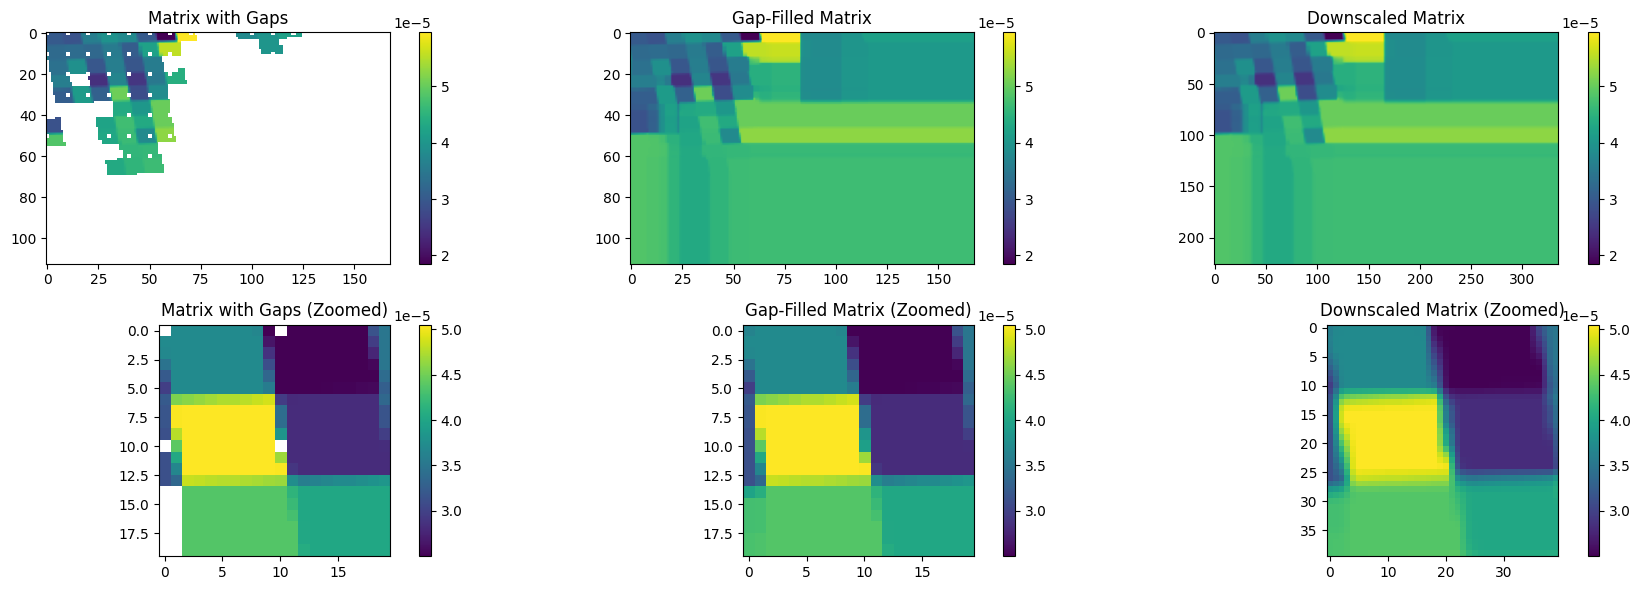

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from sklearn.ensemble import RandomForestRegressor
from scipy.ndimage import zoom  # For downscaling
from sklearn.metrics import mean_squared_error, r2_score

# Load satellite NO2 data
file_path = '/content/drive/MyDrive/drive-download-20241211T053409Z-001/Satellite_NO2_Delhi_2018_2024.tif'

# Read satellite data using rasterio
def read_tiff(file_path):
    with rasterio.open(file_path) as src:
        data = src.read()  # Read all bands
        transform = src.transform
    return data, transform

satellite_data, transform = read_tiff(file_path)

# Select a single band for demonstration (e.g., the first band)
band_data = satellite_data[0]
print("First 5 rows of the selected band:")
print(band_data[:5])

# Introduce artificial gaps for demonstration
data_with_gaps = band_data.copy()
data_with_gaps[::10, ::10] = np.nan

# Print matrix with NaN values
print("Matrix with NaN values:")
print(pd.DataFrame(data_with_gaps).head())

# Prepare data for ML-based gap filling
def prepare_ml_data(data):
    x, y = np.meshgrid(np.arange(data.shape[1]), np.arange(data.shape[0]))
    coordinates = np.column_stack((x.ravel(), y.ravel()))
    values = data.ravel()
    valid_mask = ~np.isnan(values)
    return coordinates[valid_mask], values[valid_mask], coordinates[~valid_mask]

train_features, train_labels, predict_features = prepare_ml_data(data_with_gaps)

# Train a Random Forest Regressor for gap filling
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_features, train_labels)

# Predict missing values
predicted_values = model.predict(predict_features)

# Reconstruct the matrix
def reconstruct_matrix(data, predict_features, predicted_values):
    reconstructed_data = data.copy()
    for (x, y), value in zip(predict_features, predicted_values):
        reconstructed_data[int(y), int(x)] = value
    return reconstructed_data

filled_data = reconstruct_matrix(data_with_gaps, predict_features, predicted_values)

# Ensure no negative values
filled_data[filled_data < 0] = 0

# Print gap-filled matrix
print("Gap-filled matrix:")
print(pd.DataFrame(filled_data).head())

# Downscale the data
def downscale_data(data, scale_factor):
    """
    Downscale the input matrix using bilinear interpolation.
    """
    return zoom(data, scale_factor, order=1)  # order=1 for bilinear interpolation

# Downscale the gap-filled data to a higher resolution
scale_factor = 2  # Example: double the resolution
downscaled_data = downscale_data(filled_data, scale_factor)

# Print shape of downscaled data
print(f"Original shape: {filled_data.shape}, Downscaled shape: {downscaled_data.shape}")

# Visualize the matrices side by side
def visualize_zoomed_region(original, filled, downscaled, region, title1, title2, title3):
    """
    Visualize the original, gap-filled, and downscaled matrices, including a zoomed-in region.
    """
    plt.figure(figsize=(18, 6))

    # Full matrices visualization
    plt.subplot(2, 3, 1)
    plt.title(title1)
    plt.imshow(original, cmap='viridis')
    plt.colorbar()

    plt.subplot(2, 3, 2)
    plt.title(title2)
    plt.imshow(filled, cmap='viridis')
    plt.colorbar()

    plt.subplot(2, 3, 3)
    plt.title(title3)
    plt.imshow(downscaled, cmap='viridis')
    plt.colorbar()

    # Zoomed-in region
    y_min, y_max, x_min, x_max = region

    plt.subplot(2, 3, 4)
    plt.title(f"{title1} (Zoomed)")
    plt.imshow(original[y_min:y_max, x_min:x_max], cmap='viridis')
    plt.colorbar()

    plt.subplot(2, 3, 5)
    plt.title(f"{title2} (Zoomed)")
    plt.imshow(filled[y_min:y_max, x_min:x_max], cmap='viridis')
    plt.colorbar()

    plt.subplot(2, 3, 6)
    plt.title(f"{title3} (Zoomed)")
    plt.imshow(downscaled[(y_min*scale_factor):(y_max*scale_factor),
                          (x_min*scale_factor):(x_max*scale_factor)], cmap='viridis')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# Define the region to zoom in (row and column indices)
region_to_zoom = (20, 40, 30, 50)  # Example: rows 20-40, cols 30-50

visualize_zoomed_region(
    data_with_gaps, filled_data, downscaled_data, region_to_zoom,
    "Matrix with Gaps", "Gap-Filled Matrix", "Downscaled Matrix"
)

